### Bu projede öğrencilerin sınav puanlarının akademik, davranışsal ve yaşam tarzı faktörleri kullanılarak tahmin edilmesi amaçlanmıştır.

In [1]:


import numpy as np
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/playground-series-s6e1/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e1/train.csv
/kaggle/input/competitions/playground-series-s6e1/test.csv


In [2]:
# Veri setlerini yükleme

import pandas as pd

train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e1/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e1/test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (630000, 13)
Test Shape: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
# Sütunları inceleme

train_df.columns

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [4]:
# Veri seti yapısını inceleme

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [5]:
# Sayısal özet

train_df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [6]:
# Hedef değişken dağılımı

train_df["exam_score"].describe()

count    630000.000000
mean         62.506672
std          18.916884
min          19.599000
25%          48.800000
50%          62.600000
75%          76.300000
max         100.000000
Name: exam_score, dtype: float64

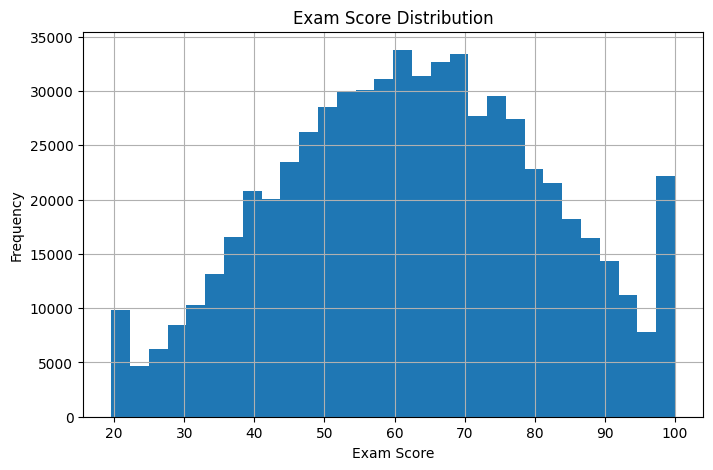

In [7]:
# Hedef değişken histogramı

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

train_df["exam_score"].hist(
    bins=30
)

plt.title("Exam Score Distribution")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

### Feature Engineering

In [8]:
#Çalışma süresi ile devam oranını birleştiriyoruz.

train_df["study_efficiency"] = (
    train_df["study_hours"] *
    train_df["class_attendance"]
)

test_df["study_efficiency"] = (
    test_df["study_hours"] *
    test_df["class_attendance"]
)

In [9]:
# Uyku kalitesi etkisi

sleep_quality_map = {
    "poor": 1,
    "average": 2,
    "good": 3
}

train_df["sleep_quality_num"] = train_df["sleep_quality"].map(sleep_quality_map)
test_df["sleep_quality_num"] = test_df["sleep_quality"].map(sleep_quality_map)

train_df["sleep_score"] = (
    train_df["sleep_hours"] *
    train_df["sleep_quality_num"]
)

test_df["sleep_score"] = (
    test_df["sleep_hours"] *
    test_df["sleep_quality_num"]
)

In [10]:
# Akademik katılım skoru

train_df["academic_engagement"] = (
    train_df["study_hours"] +
    train_df["class_attendance"] / 10
)

test_df["academic_engagement"] = (
    test_df["study_hours"] +
    test_df["class_attendance"] / 10
)

In [11]:
# Çalışma ve uyku dengesi

train_df["study_sleep_ratio"] = (
    train_df["study_hours"] /
    (train_df["sleep_hours"] + 1)
)

test_df["study_sleep_ratio"] = (
    test_df["study_hours"] /
    (test_df["sleep_hours"] + 1)
)

In [13]:
# Yeni değişkenleri kontrol ediyoruz.

train_df[
    [
        "study_efficiency",
        "sleep_score",
        "academic_engagement",
        "study_sleep_ratio"
    ]
].describe()

,study_efficiency,sleep_score,academic_engagement,study_sleep_ratio
count,630000.000000,630000.000000,630000.000000,630000.000000
mean,291.721255,14.175579,11.201064,0.518414
std,193.177520,7.007145,3.054162,0.332483
min,3.248000,4.100000,4.140000,0.007339
25%,129.630000,8.300000,8.940000,0.244048
50%,269.010000,13.200000,11.190000,0.495062
75%,431.257500,18.800000,13.530000,0.744304
max,786.254000,29.700000,17.850000,1.550980


In [14]:
# Kategorik değişkenleri belirleme

categorical_features = [
    "gender",
    "course",
    "internet_access",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]

In [15]:
# Eğitim ve doğrulama verilerini ayırma

from sklearn.model_selection import train_test_split

x = train_df.drop(["id", "exam_score"], axis=1)
y = train_df["exam_score"]

x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print(x_train.shape)
print(x_valid.shape)

(504000, 16)
(126000, 16)


In [16]:
# CatBoost modeli kurma

from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=42,
    verbose=100
)

model.fit(
    x_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(x_valid, y_valid),
    use_best_model=True
)

0:	learn: 18.2884281	test: 18.2173471	best: 18.2173471 (0)	total: 573ms	remaining: 9m 32s
100:	learn: 8.8687012	test: 8.8637701	best: 8.8637701 (100)	total: 41.4s	remaining: 6m 8s
200:	learn: 8.8319973	test: 8.8333079	best: 8.8333079 (200)	total: 1m 22s	remaining: 5m 26s
300:	learn: 8.8093803	test: 8.8174597	best: 8.8174597 (300)	total: 2m 3s	remaining: 4m 45s
400:	learn: 8.7866906	test: 8.8025465	best: 8.8025465 (400)	total: 2m 49s	remaining: 4m 12s
500:	learn: 8.7677259	test: 8.7931900	best: 8.7931900 (500)	total: 3m 34s	remaining: 3m 33s
600:	learn: 8.7501135	test: 8.7841737	best: 8.7841737 (600)	total: 4m 19s	remaining: 2m 52s
700:	learn: 8.7350970	test: 8.7781221	best: 8.7781120 (699)	total: 5m 2s	remaining: 2m 9s
800:	learn: 8.7220996	test: 8.7733782	best: 8.7733782 (800)	total: 5m 46s	remaining: 1m 25s
900:	learn: 8.7093378	test: 8.7693005	best: 8.7693005 (900)	total: 6m 30s	remaining: 42.9s
999:	learn: 8.6976388	test: 8.7661502	best: 8.7661502 (999)	total: 7m 13s	remaining: 0us

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=100)

In [17]:
# Doğrulama performansı

from sklearn.metrics import root_mean_squared_error

predictions = model.predict(x_valid)

rmse = root_mean_squared_error(
    y_valid,
    predictions
)

print("Validation RMSE:", rmse)

Validation RMSE: 8.76615014529082


In [18]:
# Feature engineering değişkenlerinin hedef ile ilişkisi

numeric_features = [
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "study_efficiency",
    "sleep_score",
    "academic_engagement",
    "study_sleep_ratio",
    "exam_score"
]

train_df[numeric_features].corr()["exam_score"].sort_values(
    ascending=False
)

exam_score             1.000000
study_efficiency       0.796722
academic_engagement    0.794983
study_hours            0.762267
study_sleep_ratio      0.646040
class_attendance       0.360954
sleep_score            0.278864
sleep_hours            0.167410
Name: exam_score, dtype: float64

In [19]:
# Test tahminleri

test_predictions = model.predict(
    test_df.drop("id", axis=1)
)

submission = pd.DataFrame({
    "id": test_df["id"],
    "exam_score": test_predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,id,exam_score
0,630000,72.040776
1,630001,70.757968
2,630002,87.547853
3,630003,55.407343
4,630004,47.464638


### Kurulan CatBoost modeli doğrulama verisi üzerinde yaklaşık 8.77 RMSE değeri elde etmiş ve Kaggle yarışmasında 8.75421 Public Score sonucuna ulaşmıştır. Özellik mühendisliği çalışmaları sonucunda özellikle çalışma süresi, ders devam oranı ve bu değişkenlerden türetilen akademik katılım göstergelerinin sınav başarısını açıklamada önemli rol oynadığı görülmüştür. Elde edilen sonuçlar öğrenci performansının yalnızca akademik değil aynı zamanda davranışsal alışkanlıklarla da güçlü şekilde ilişkili olduğunu göstermektedir.

In [20]:
# Model kaydetme

model.save_model("student_score_model.cbm")

In [21]:
# Feature sütunlarını kaydetme

import joblib

feature_columns = x_train.columns.tolist()

joblib.dump(feature_columns,"feature_columns.pkl")

['feature_columns.pkl']

In [22]:
# Kategorik değişkenleri kaydetme

joblib.dump(categorical_features,"categorical_features.pkl")

['categorical_features.pkl']